In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Loading the data
df=pd.read_csv("netflix_titles.csv")

In [4]:
# Cleaning the data
df=df.dropna(subset=['type', 'release_year', 'rating', 'country', 'duration'])

value_counts() counts how many times each unique value appears.  

type_counts.index Gives the category names:['Movie', 'TV Show']
These are used on the X-axis.

type_counts.values Gives the frequencies:[6131, 2676]
These are used on the Y-axis.

type
Movie      5687
TV Show    2283
Name: count, dtype: int64


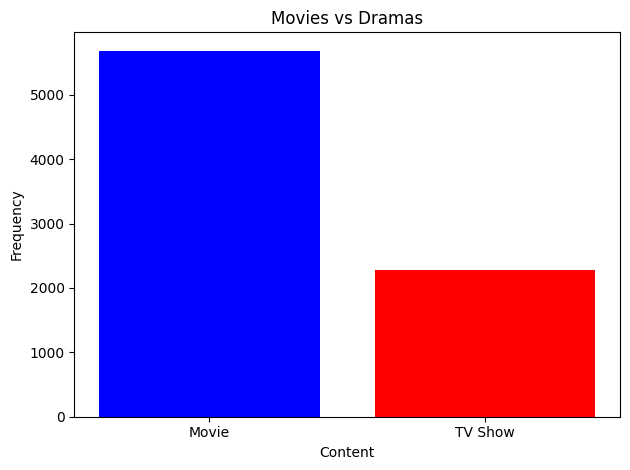

In [12]:
type_counts = df['type'].value_counts()
print(type_counts)
plt.bar(type_counts.index, type_counts.values, color=['blue','red'])
plt.title('Movies vs Dramas')
plt.xlabel('Content')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Movies_Dramas.png')
plt.show()

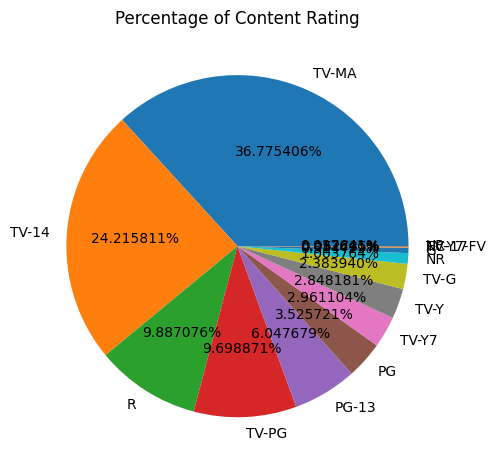

In [11]:
rating_counts = df['rating'].value_counts()
plt.pie(rating_counts.values,labels=rating_counts.index,autopct='%1f%%')
plt.title('Percentage of Content Rating')
plt.tight_layout()
plt.savefig('rating_precentage.png')
plt.show()

df['type'] == 'Movie' : Keeps only rows where type is Movie.  

.copy() : creates a separate safe copy.Now movie_df contains only rows where type=movies, not TV shows.  

.str.replace(' min', '') Removes the text " min" in the duration column into :"90","120","45"  

✔ .astype(int) : Converts strings into integers: 90,120,45

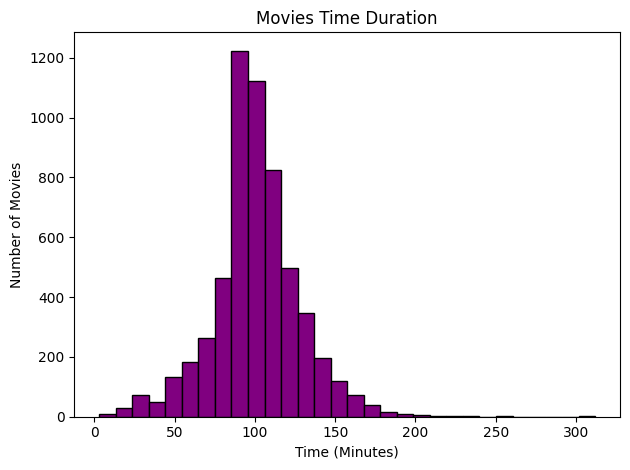

In [14]:
movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace(' min', '').astype(int)
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')
plt.title('Movies Time Duration')
plt.xlabel('Time (Minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('Movies_Duration.png')
plt.show()

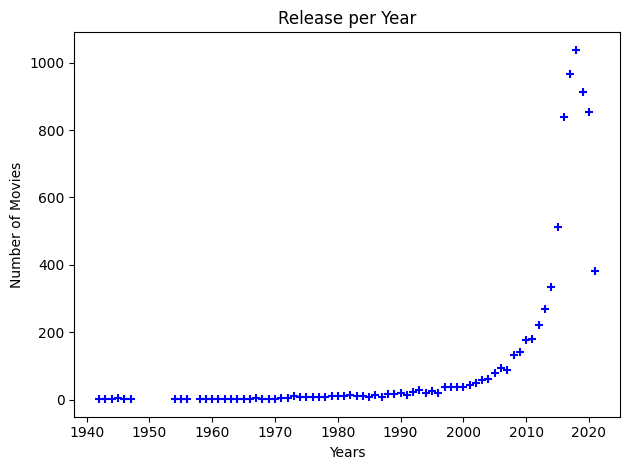

In [17]:
release_year_df=df['release_year'].value_counts()
plt.scatter(release_year_df.index,release_year_df.values,marker='+',color='blue')
plt.title('Release per Year')
plt.xlabel('Years')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('Release_per_Year.png')
plt.show()

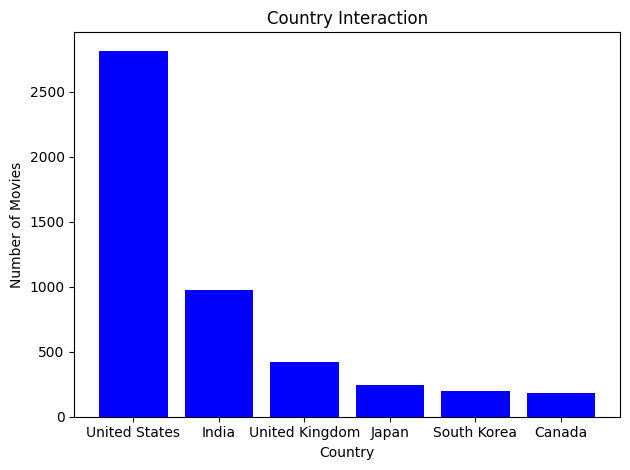

In [31]:
country_df=df['country'].value_counts().head(6)
# Country_df had a sorted values table and head will pick the first 6 rows.
plt.bar(country_df.index,country_df.values,color='blue')
plt.Figure(figsize=(8,6))
plt.title('Country Interaction')
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('Top6_Countries.png')
plt.show()

**groupdataby** : Group the data by release_year and type (Movie / TV Show).    
Group 1 (2020, Movie)  
Group 2 (2020, TV Show)  
Group 3 (2021, Movie)  and so on....  

**.size** : Counts how many rows are in each group.  

Example output:  
2020 -> movie=120 and TV Show=80  
2021 -> movie=150 and TV Show=90  
👉 This is a MultiIndex Series

**.unstack** : Converts rows into columns.

Before:  
movie=120 and TV Show=80  
movie=150 and TV Show=90  

After .unstack():

| release_year | Movie | TV Show |
| ------------ | ----- | ------- |
| 2020         | 120   | 80      |
| 2021         | 150   | 90      |

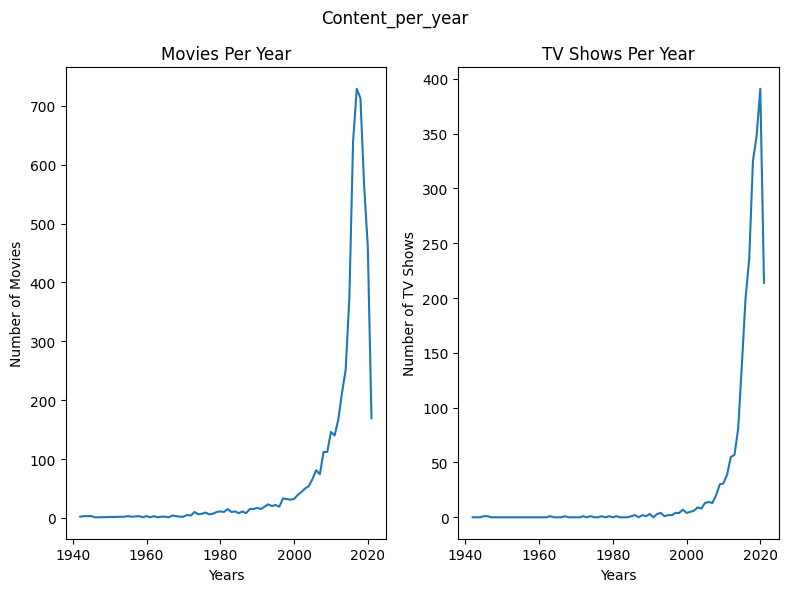

In [38]:
content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig,ax =plt.subplots(1,2, figsize=(8,6))
ax[0].plot(content_by_year.index,content_by_year['Movie'])
ax[0].set_title('Movies Per Year')
ax[0].set_xlabel('Years')
ax[0].set_ylabel('Number of Movies')

ax[1].plot(content_by_year.index,content_by_year['TV Show'])
ax[1].set_title('TV Shows Per Year')
ax[1].set_xlabel('Years')
ax[1].set_ylabel('Number of TV Shows')
plt.suptitle("Content_per_year")
plt.tight_layout()
plt.savefig('Content_per_year.png')

___
### Project Is Ended !!!
___